# 🌸 Iris Flower Classification using KNN
## Project Overview
In this project, I aim to classify three species of the Iris flower (**Setosa, Versicolor, and Virginica**) based on four physical measurements:
* Sepal Length
* Sepal Width
* Petal Length
* Petal Width

### 🛠️ Techniques Used:
1. **Data Exploration** (Pandas & Seaborn)
2. **Feature Scaling** (StandardScaler)
3. **Machine Learning Model** (K-Nearest Neighbors - KNN)
4. **Evaluation Metrics** (Accuracy, Confusion Matrix, Classification Report)

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('1) iris.csv')

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 📝 Column Descriptions

1. **sepal_length**: The length of the sepal (the outer part of the flower) in centimeters.
2. **sepal_width**: The width of the sepal in centimeters.
3. **petal_length**: The length of the petal (the colored part of the flower) in centimeters.
4. **petal_width**: The width of the petal in centimeters.
5. **species**: The target class (label). It includes three types: **Setosa, Versicolor, and Virginica**.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### 📊 Statistical Summary Analysis

From the descriptive statistics above, we can observe:
- **Count:** There are **150** samples in the dataset with no missing values.
- **Mean & Std:** The average **Sepal Length** is ~5.8 cm, while the **Petal Length** shows a much higher standard deviation (1.76), indicating more variation in petal sizes between species.
- **Range:** - **Petal Length** ranges from **1.0 cm to 6.9 cm**, which is a wide range that will help the model distinguish between species easily.
    - **Petal Width** also shows a clear gap between the minimum (0.1) and maximum (2.5).
- **Conclusion:** Since the scales of features are relatively close (all between 0.1 and 7.9), KNN will perform well, but **Scaling** is still recommended for optimal distance calculation.

### 🌸 Visualizing Species Relationships
The **Pairplot** shows how each species forms a distinct cluster. We can clearly see that **Setosa** is easily separable from the others.

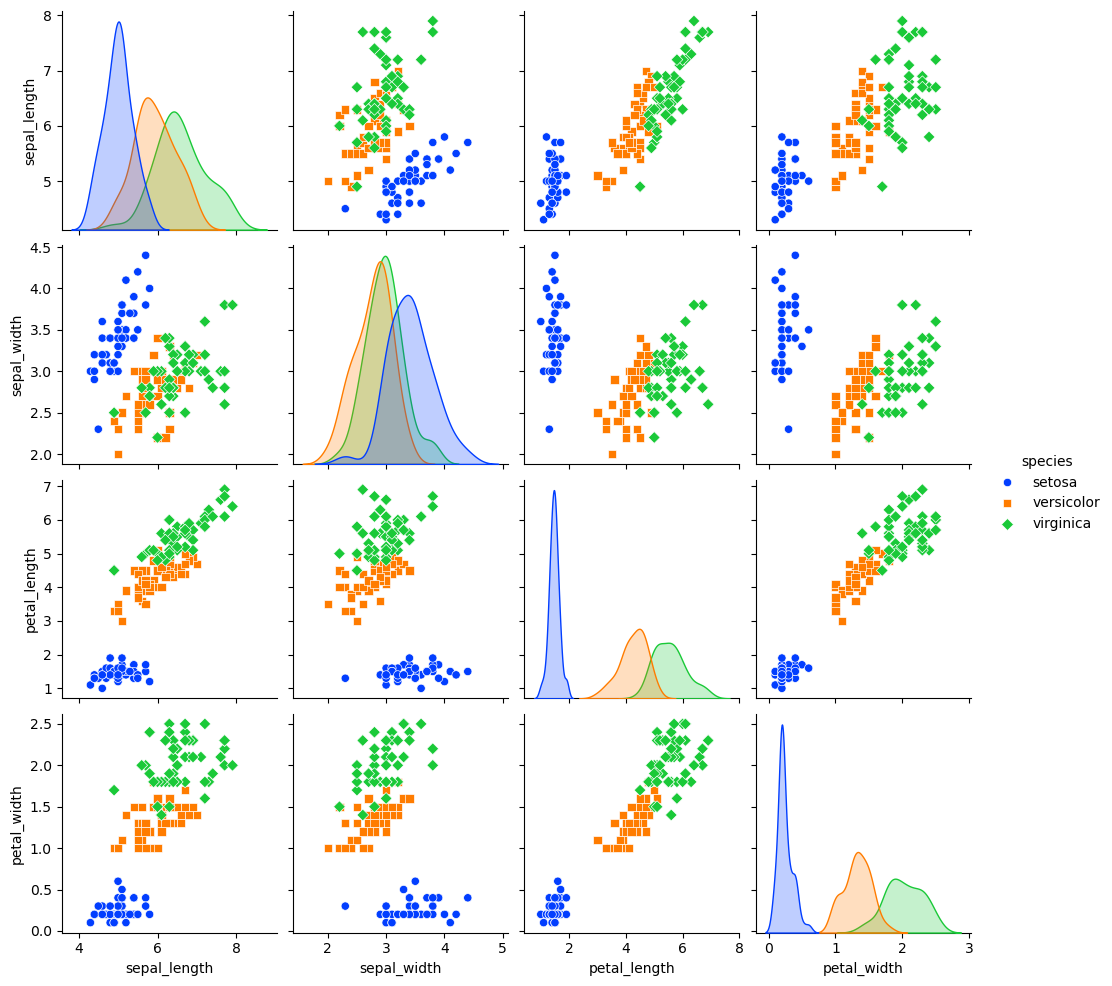

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df, hue='species', markers=["o", "s", "D"], palette='bright')
plt.show()

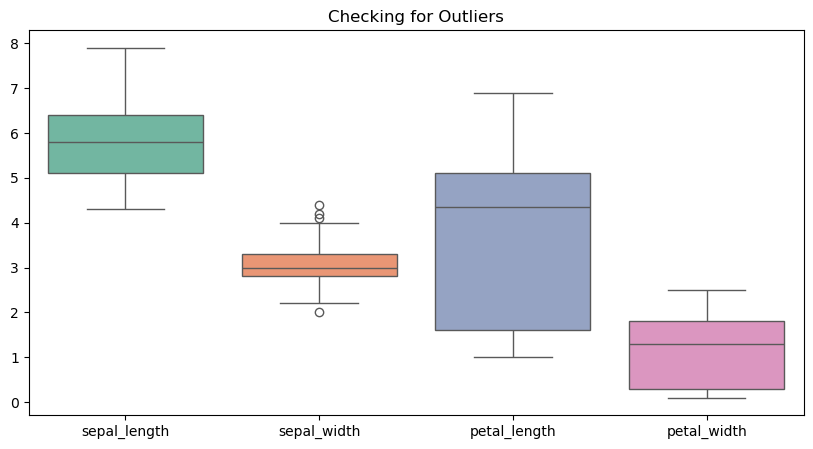

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df.iloc[:, :-1], palette='Set2')
plt.title("Checking for Outliers")
plt.show()

### 3. Data Preprocessing & Modeling
- **Splitting:** Dividing the data into 80% training and 20% testing.
- **Scaling:** Normalizing the features for KNN (Distance-based model).
- **Hyperparameter Tuning:** Finding the best value for 'K'.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = df.drop('species', axis=1)
y = df['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
k_range = range(1, 21)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

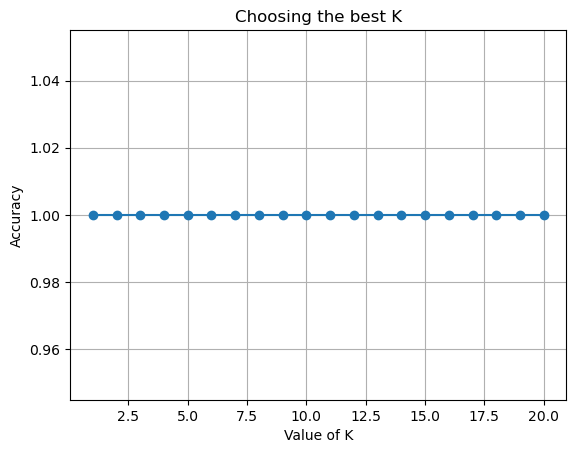

In [11]:
plt.plot(k_range, scores, marker='o')
plt.xlabel('Value of K')
plt.ylabel('Accuracy')
plt.title('Choosing the best K')
plt.grid()
plt.show()

### 4. Final Model Evaluation
We chose **K=3** (or the best observed K) and evaluated the performance using a Confusion Matrix.

In [12]:
final_knn = KNeighborsClassifier(n_neighbors=3)
final_knn.fit(X_train, y_train)
y_pred = final_knn.predict(X_test)
print(f"Final Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Final Accuracy: 100.00%


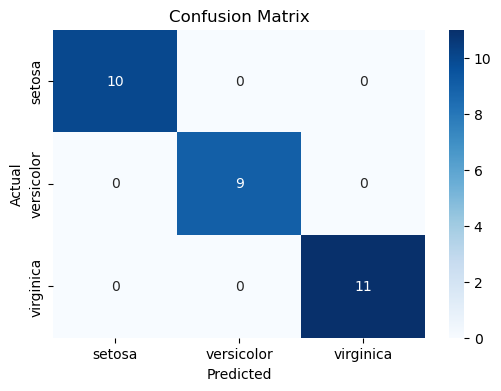

In [13]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', xticklabels=df['species'].unique(), yticklabels=df['species'].unique())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()